# Definición

Sea $P_e$ un operador lineal de la forma

\begin{align*}
    &P_e : \mathbb{C}^2 \rightarrow  \mathbb{C}^2\\
    &\quad\quad \hat{v} \mapsto P_e\hat{v}
\end{align*}

se define a $P_e$ como un **polarizador elíptico** si para cualquier vector de Jones $\hat{v}\in \mathbb{C}^2$ el vector resultante puede caracterizarse por dos ángulos $ -\pi \leq \alpha \leq \pi$, $-\frac{\pi}{4} \leq \chi \leq \frac{\pi}{4}$ tales que $P_e\hat{v}=\ket{\alpha,\chi}$. En caso contrario, al operador $P_e$ se le denominará **generador elíptico**.

La anterior definición es equivalente a definir que al operador $P_e$ se le llamará polarizador elíptico si la matriz de Mueller $M_e$ asociada al operador $P_e$ puede generar cualquier estado sobre la esfera de Poincaré. En caso contrario, al operador $P_e$ asociada a la matriz de Mueller $M_e$ se le denominará generador elíptico.

## Esquema experimental de generación de un polarizador elíptico tuneable

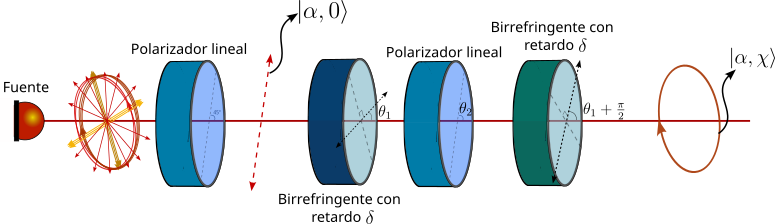

El sistema que generará al proyecto $P_e$ tal que su comportamiento es el de un polarizador elíptico consiste en un birrefringente de retardo $\delta$ rotado espacialmente un ángulo de $\theta_1$ seguido de un polarizador lineal rotado espacialmente con un ángulo $\theta_2$ y el tercer elemento será un birrefringente idéntico al primero, pero su ángulo de rotación será $\theta_2+\frac{\pi}{2}$. A continuación se muestra el desarrollo teórico de dicho esquema

In [1]:
import sympy as sp
import numpy as np
import Distributions as distri
import plotly.graph_objects as go
from sympy import I
from sympy.physics.quantum import TensorProduct

alpha , chi , delta  = sp.symbols('\\alpha \\chi \\delta', real=True)
pi = sp.pi
theta1 , theta2 , p , q = sp.symbols('\\theta_1 \\theta_2 p q',real=True)
vecE = sp.Matrix(
    [
        sp.cos(chi),
        I*sp.sin(chi)
    ]
)

# L4 = sp.exp(-I * pi /4)*sp.Matrix(
#     [
#         [1 , 0],
#         [0,sp.exp(I * pi/2)]
#     ]
# )

L4 = sp.exp(-I * pi /4)*sp.Matrix(
    [
        [sp.exp(I * pi/2) , 0],
        [0,1]
    ]
)

LDelta = sp.exp(-I * delta) * sp.Matrix(
    [
        [1 , 0],
        [0 , sp.exp(2 * I * delta)]
    ]
)

Rtheta1 = sp.Matrix(
    [
        [sp.cos(theta1) , sp.sin(theta1)],
        [-sp.sin(theta1) , sp.cos(theta1)]
    ]
)

Rtheta2 = sp.Matrix(
    [
        [sp.cos(theta1 + pi/2) , sp.sin(theta1 + pi/2)],
        [-sp.sin(theta1 + pi/2) , sp.cos(theta1 + pi/2)]
    ]
)

PolLin = sp.Matrix(
    [
        [(sp.cos(theta2))**2 , sp.cos(theta2) * sp.sin(theta2)],
        [sp.sin(theta2) * sp.cos(theta2) , ( sp.sin(theta2) )**2]
    ]
)

L4_T1 = Rtheta1.transpose() * L4 * Rtheta1
L4_T2 = Rtheta2.transpose() * L4 * Rtheta2
LDelta_T1 = Rtheta1.transpose() * LDelta * Rtheta1
LDelta_T2 = Rtheta2.transpose() * LDelta * Rtheta2

# P_esquema = LDelta_T2 * PolLin * LDelta_T1
P_esquema = L4_T2 * PolLin * L4_T1
P_esquema.simplify()
P_esquema = sp.expand(P_esquema)
P_esquema

Matrix([
[                             cos(2*\theta_2)/4 + cos(4*\theta_1 - 2*\theta_2)/4 + 1/2, sin(2*\theta_2)/4 + I*sin(2*\theta_1 - 2*\theta_2)/2 + sin(4*\theta_1 - 2*\theta_2)/4],
[sin(2*\theta_2)/4 - I*sin(2*\theta_1 - 2*\theta_2)/2 + sin(4*\theta_1 - 2*\theta_2)/4,                             -cos(2*\theta_2)/4 - cos(4*\theta_1 - 2*\theta_2)/4 + 1/2]])

In [2]:
vecE = sp.Matrix(
    [
        sp.cos(chi),
        I*sp.sin(chi)
    ]
)
rotalpha = sp.Matrix(
    [
        [sp.cos(alpha) , -sp.sin(alpha)],
        [sp.sin(alpha) , sp.cos(alpha)]
    ]
)
vecE = rotalpha * vecE
vecE
proy = vecE*vecE.adjoint()
proy = sp.simplify(proy)
proy

Matrix([
[            cos(2*\alpha - 2*\chi)/4 + cos(2*\alpha + 2*\chi)/4 + 1/2, -I*sin(2*\chi)/2 + sin(2*\alpha - 2*\chi)/4 + sin(2*\alpha + 2*\chi)/4],
[I*sin(2*\chi)/2 + sin(2*\alpha - 2*\chi)/4 + sin(2*\alpha + 2*\chi)/4,             -cos(2*\alpha - 2*\chi)/4 - cos(2*\alpha + 2*\chi)/4 + 1/2]])

In [3]:
Pe12 = P_esquema[0,1]
Pe12_op1 = Pe12.subs(theta1,alpha)
Pe12_op1 = Pe12_op1.subs(theta2,alpha-chi)
Pe12_op1

I*sin(2*\chi)/2 + sin(2*\alpha - 2*\chi)/4 + sin(2*\alpha + 2*\chi)/4

In [4]:
Pe12

sin(2*\theta_2)/4 + I*sin(2*\theta_1 - 2*\theta_2)/2 + sin(4*\theta_1 - 2*\theta_2)/4

In [5]:
Pe12_op2 = Pe12.subs(theta1,alpha)
Pe12_op2 = Pe12_op2.subs(theta2,-alpha+chi)
Pe12_op2

-sin(2*\alpha - 2*\chi)/4 + I*sin(4*\alpha - 2*\chi)/2 + sin(6*\alpha - 2*\chi)/4

In [6]:
proy[0,1]

-I*sin(2*\chi)/2 + sin(2*\alpha - 2*\chi)/4 + sin(2*\alpha + 2*\chi)/4

# Ligaduras entre ángulos de rotación y ángulos característicos

Al igualar componente a componente y resolver, se obtienen la siguiente relación matemática

$$
 2sen(2\theta_1)sen(2\theta_1-2\theta_2)[cos(2\delta)+1] = 2cos(2\alpha)cos(2\chi),
$$
en donde se obtienen las siguientes ecuaciones

$$
    \theta_1 = \alpha - \pi/2, \quad \quad \theta_2 = \alpha - \chi,
$$

**Antes de proceder con el operador y deducir alguna otra ligadura para $\delta$, vale la pena observar el sistema de ecuaciones, en donde vemos que no solo con estas ecuaciones para $\theta_{1,2}$ es suficiente para garantizar la igualdad, sino que se debería cumplir que $cos(2\delta)+1=1 \rightarrow 2\delta = \frac{\pi}{2}+2n\pi, \; n \in \mathbb{N}$ lo que implica que el retardo para que $P_e$ sea un polarizador elíptica, ha de ser $\delta= \frac{\pi}{4} + 2n\pi,\; n\in \mathbb{N}$**


por lo tanto, el operador será

In [7]:
P_e = P_esquema.subs(theta1,alpha - pi)
P_e = P_e.subs(theta2,alpha - chi)
P_e = sp.simplify(P_e)
P_e.expand()

Matrix([
[             cos(2*\alpha - 2*\chi)/4 + cos(2*\alpha + 2*\chi)/4 + 1/2, I*sin(2*\chi)/2 + sin(2*\alpha - 2*\chi)/4 + sin(2*\alpha + 2*\chi)/4],
[-I*sin(2*\chi)/2 + sin(2*\alpha - 2*\chi)/4 + sin(2*\alpha + 2*\chi)/4,            -cos(2*\alpha - 2*\chi)/4 - cos(2*\alpha + 2*\chi)/4 + 1/2]])

## Ligadura sobre el retardo $\delta$

Por definición, si $P_e$ es un polarizador lineal entonces debe garantizar la proyección sobre cualquier estado elíptico posible, por lo tanto, para que nuestro operador $P_e$ satisfaga esta definición se debe cumplir que para cualquier par $\alpha,\chi$ existan un operador ortogonal, tal que aniquile el estado de entrada.

En este orden de ideas, vamos a partir de un operador con $\chi$ y $\alpha$ arbitrario, y el operador ortogonal sería el que tenga por parámetro a $\chi'=\chi+\pi/2$.

In [8]:
P_e_lin = P_e
P_e_lin_perp = P_e_lin.subs(chi, chi + pi/2)
Ef = P_e_lin_perp * ( P_e_lin * vecE )
Ef

Matrix([
[((sin(\alpha)*cos(\chi) + I*sin(\chi)*cos(\alpha))*(I*sin(2*\chi)/2 + sin(2*\alpha - 2*\chi)/4 + sin(2*\alpha + 2*\chi)/4) + (-I*sin(\alpha)*sin(\chi) + cos(\alpha)*cos(\chi))*(cos(2*\alpha - 2*\chi)/4 + cos(2*\alpha + 2*\chi)/4 + 1/2))*(-cos(2*\alpha - 2*\chi)/4 - cos(2*\alpha + 2*\chi)/4 + 1/2) + ((sin(\alpha)*cos(\chi) + I*sin(\chi)*cos(\alpha))*(-cos(2*\alpha - 2*\chi)/4 - cos(2*\alpha + 2*\chi)/4 + 1/2) + (-I*sin(\alpha)*sin(\chi) + cos(\alpha)*cos(\chi))*(-I*sin(2*\chi)/2 + sin(2*\alpha - 2*\chi)/4 + sin(2*\alpha + 2*\chi)/4))*(-I*sin(2*\chi)/2 - sin(2*\alpha - 2*\chi)/4 - sin(2*\alpha + 2*\chi)/4)],
[  ((sin(\alpha)*cos(\chi) + I*sin(\chi)*cos(\alpha))*(I*sin(2*\chi)/2 + sin(2*\alpha - 2*\chi)/4 + sin(2*\alpha + 2*\chi)/4) + (-I*sin(\alpha)*sin(\chi) + cos(\alpha)*cos(\chi))*(cos(2*\alpha - 2*\chi)/4 + cos(2*\alpha + 2*\chi)/4 + 1/2))*(I*sin(2*\chi)/2 - sin(2*\alpha - 2*\chi)/4 - sin(2*\alpha + 2*\chi)/4) + ((sin(\alpha)*cos(\chi) + I*sin(\chi)*cos(\alpha))*(-cos(2*\al

In [9]:
Ef.expand()

Matrix([
[ I*sin(\alpha)*sin(\chi)*sin(2*\chi)**2/4 + I*sin(\alpha)*sin(\chi)*sin(2*\alpha - 2*\chi)**2/16 + I*sin(\alpha)*sin(\chi)*sin(2*\alpha - 2*\chi)*sin(2*\alpha + 2*\chi)/8 + I*sin(\alpha)*sin(\chi)*sin(2*\alpha + 2*\chi)**2/16 + I*sin(\alpha)*sin(\chi)*cos(2*\alpha - 2*\chi)**2/16 + I*sin(\alpha)*sin(\chi)*cos(2*\alpha - 2*\chi)*cos(2*\alpha + 2*\chi)/8 + I*sin(\alpha)*sin(\chi)*cos(2*\alpha + 2*\chi)**2/16 - I*sin(\alpha)*sin(\chi)/4 - sin(2*\chi)**2*cos(\alpha)*cos(\chi)/4 - sin(2*\alpha - 2*\chi)**2*cos(\alpha)*cos(\chi)/16 - sin(2*\alpha - 2*\chi)*sin(2*\alpha + 2*\chi)*cos(\alpha)*cos(\chi)/8 - sin(2*\alpha + 2*\chi)**2*cos(\alpha)*cos(\chi)/16 - cos(\alpha)*cos(\chi)*cos(2*\alpha - 2*\chi)**2/16 - cos(\alpha)*cos(\chi)*cos(2*\alpha - 2*\chi)*cos(2*\alpha + 2*\chi)/8 - cos(\alpha)*cos(\chi)*cos(2*\alpha + 2*\chi)**2/16 + cos(\alpha)*cos(\chi)/4],
[-sin(\alpha)*sin(2*\chi)**2*cos(\chi)/4 - sin(\alpha)*sin(2*\alpha - 2*\chi)**2*cos(\chi)/16 - sin(\alpha)*sin(2*\alpha - 2*\c

## Lema: Un operador $P_e$ que representa el transformación de polarización mediante una lámina retardadora con retardo $\delta$, rotada un ángulo $\theta_1$, seguida de un polarizador lineal rotado a un ángulo $\theta_2$ y seguido por una lámina retardadora $\delta$ es un polarizador elíptico si y solo si, $\theta_1=\alpha-\pi/2 + 2n\pi$, $\theta_2 = \alpha - \chi + 2n\pi$ $\delta = \pi/4 + 2n\pi$ donde $n$ es algún número entero. 

**Demostración**

$[\Rightarrow$ Esta demostración es la que se ha desarrollado a lo largo de este cuaderno de Jupyter, en el cual se obtiene que si $P_e$ es un polarizador elíptico entonces $\delta = \pi/4 + 2n\pi$.

$\Leftarrow]$ Sea $P_e$ el polarizador del esquema obtenido en este cuaderno de Jupyter, y sea $\theta_1=\alpha - \pi/2$, $\theta_2 = \alpha-\chi$ y $\delta = \pi/4 $, vamos a demostrar que este operador $P_e$ bajo estas condiciones, da a lugar al mismo operador de proyección $\ket{\alpha,\chi}\bra{\alpha,\chi}$

In [10]:
P_prop = P_esquema.subs(theta1, alpha - pi/2)
P_prop = P_prop.subs(theta2,alpha - chi)
P_prop = P_prop.subs(delta, pi/4)
P_prop.simplify()

Matrix([
[            cos(2*\alpha - 2*\chi)/4 + cos(2*\alpha + 2*\chi)/4 + 1/2, -I*sin(2*\chi)/2 + sin(2*\alpha - 2*\chi)/4 + sin(2*\alpha + 2*\chi)/4],
[I*sin(2*\chi)/2 + sin(2*\alpha - 2*\chi)/4 + sin(2*\alpha + 2*\chi)/4,             -cos(2*\alpha - 2*\chi)/4 - cos(2*\alpha + 2*\chi)/4 + 1/2]])

In [11]:
proy

Matrix([
[            cos(2*\alpha - 2*\chi)/4 + cos(2*\alpha + 2*\chi)/4 + 1/2, -I*sin(2*\chi)/2 + sin(2*\alpha - 2*\chi)/4 + sin(2*\alpha + 2*\chi)/4],
[I*sin(2*\chi)/2 + sin(2*\alpha - 2*\chi)/4 + sin(2*\alpha + 2*\chi)/4,             -cos(2*\alpha - 2*\chi)/4 - cos(2*\alpha + 2*\chi)/4 + 1/2]])

**Observamos que se demuestra entonces que bajo estas condiciones el operador $P_e$ es un polarizador elíptico.**

## Teorema: Si un operador $P_e$ es un polarizador elíptico, entonces implica una ley de Malus generalizada tal que para ángulo de elipticidad nulos se reduce a la ley de Malus tradicional.

**Demostración**: Partamos del lema anterior y de la expresión para un polarizador elíptico $P_e$ el cual tiene la forma

$$
    P_e = 
    \begin{bmatrix}
        \frac{cos(2\alpha - 2\chi)}{4} + \frac{cos(2\alpha + 2\chi)}{4} + \frac{1}{2} & - \frac{isen(2\chi)}{2} + \frac{sen(2\alpha - 2\chi)}{4} + \frac{sen(2\alpha + 2\chi)}{4}\\
        \frac{isen(2\chi)}{2}+\frac{sen(2\alpha-2\chi)}{4} + \frac{sen(2\alpha + 2\chi)}{4} & - \frac{cos(2\alpha -2\chi)}{4} - \frac{cos(2\alpha + 2\chi)}{4} + \frac{1}{2}
    \end{bmatrix}
$$

In [12]:
omega = sp.symbols('\\omega')
proy2 = P_esquema.subs(delta,pi/4)
Vec_0 = proy2 * vecE
Vec_0 = sp.simplify(Vec_0)

E0 = Vec_0[0]
E1 = Vec_0[1]
intensity = E0 * sp.conjugate(E0) + E1 * sp.conjugate(E1)
intensity = intensity.simplify()

intensity = intensity.subs(theta1, theta1+omega)
intensity = intensity.subs(theta2, theta2+omega)
intensity = intensity.subs(theta1, alpha - pi/2)
intensity = intensity.subs(theta2, alpha-chi)
intensity = intensity.simplify()
intensity

-cos(4*\chi)/4 + cos(2*\omega)/4 + cos(4*\chi - 2*\omega)/8 + cos(4*\chi + 2*\omega)/8 + 3/4

In [13]:
intensity.subs(chi,0)

cos(2*\omega)/2 + 1/2

# Visualized geometrical law

In [14]:
P_esquema.subs(delta, pi/4)

Matrix([
[                             cos(2*\theta_2)/4 + cos(4*\theta_1 - 2*\theta_2)/4 + 1/2, sin(2*\theta_2)/4 + I*sin(2*\theta_1 - 2*\theta_2)/2 + sin(4*\theta_1 - 2*\theta_2)/4],
[sin(2*\theta_2)/4 - I*sin(2*\theta_1 - 2*\theta_2)/2 + sin(4*\theta_1 - 2*\theta_2)/4,                             -cos(2*\theta_2)/4 - cos(4*\theta_1 - 2*\theta_2)/4 + 1/2]])

In [15]:
def OperatePol(vecE):
    
    alpha_rand = 2 * pi * np.random.random()
    chi_rand = pi * np.random.random()
    theta1_rand = 2 * pi * np.random.random()
    theta2_rand = 2 * pi * np.random.random()
        
    theta_arr = 2 * pi * np.arange(0, 1 , 0.005)
    theta1_arr = theta1_rand + 2 * np.pi * np.arange(0 , 1 , 0.005)
    theta2_arr = theta2_rand + 2 * np.pi * np.arange(0 , 1 , 0.005)
    thetas_arr = 2 * np.pi * np.arange(0, 1 , 0.005)
    
    P_es = P_esquema.subs(delta, pi/4)
    PolIn = P_es.subs(theta1,theta1_rand)
    PolIn = PolIn.subs(theta2,theta2_rand)
    PolIn = PolIn.evalf()
    PolIn = sp.simplify(PolIn)
    
    State_0 = vecE.subs(alpha,alpha_rand)
    State_0 = State_0.subs(chi,chi_rand)
    State_0 = State_0.evalf()
    State_0 = sp.simplify(State_0)
    State_0 = PolIn * State_0
    S0_arr = []
    S1_arr = []
    S2_arr = []
    S3_arr = []
    
    for theta in theta_arr:
        
        PolRot = P_es.subs(theta1,theta1_rand + theta)
        PolRot = PolRot.subs(theta2,theta2_rand + theta)
        PolRot = PolRot.evalf()

        State_F = PolRot * State_0
        State_F = State_F.evalf()
        
        S0 = State_F[0] * sp.conjugate(State_F[0]) + State_F[1] * sp.conjugate(State_F[1])
        S0 = S0.evalf()
        S0 = sp.simplify(S0)
        
        S1 = State_F[0] * sp.conjugate(State_F[0]) - State_F[1] * sp.conjugate(State_F[1])
        S1 = S1.evalf()
        S1 = sp.simplify(S1)
        
        S2 = State_F[0] * sp.conjugate(State_F[1]) + State_F[1] * sp.conjugate(State_F[0])
        S2 = S2.evalf()
        S2 = sp.simplify(S2)
        S2 = sp.re(S2)
        
        S3 = I * (State_F[0] * sp.conjugate(State_F[1]) - State_F[1] * sp.conjugate(State_F[0]))
        S3 = S3.evalf()
        S3 = sp.simplify(S3)
        S3 = sp.re(S3)
        
        S0_arr.append(S0)
        S1_arr.append(S1)
        S2_arr.append(S2)
        S3_arr.append(S3)
        
    S1_arr = np.array(S1_arr)
    S2_arr = np.array(S2_arr)
    S3_arr = np.array(S3_arr)
    
    S1_arr = S1_arr / S0_arr
    S2_arr = S2_arr / S0_arr
    S3_arr = S3_arr / S0_arr
    S = np.zeros((len(S0_arr),3))
    S[:,0] = S1_arr
    S[:,1] = S2_arr
    S[:,2] = S3_arr    
    
    Data = np.array([theta1_rand + np.pi / 2 , theta1_rand - theta2_rand + np.pi/2, alpha_rand , chi_rand])
    return Data , thetas_arr , S0_arr , S

In [16]:
Data, theta_arr , S0  , S = OperatePol(vecE)
S0 = np.array(S0, dtype=float) 
Data[0] = Data[0].evalf()
Data[1] = Data[1].evalf()
Data[2] = Data[2].evalf()
Data[3] = Data[3].evalf()

Data[0] = round(Data[0],2)
Data[1] = round(Data[1],2)
Data[2] = round(Data[2],2)
Data[3] = round(Data[3],2)

In [17]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=theta_arr,
    y=S0,
    name=f'Estado Incidente alpha={Data[2]} y chi={Data[3]}',
    mode='lines'
))

fig.update_layout(
    title=f'Ley de Malus para polarizador con alpha={Data[0]} y chi={Data[1]}',
    xaxis_title='Ángulo (theta)',
    yaxis_title='Intensidad',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    hovermode="x unified",
    
    yaxis=dict(showgrid=True, gridcolor='lightgray'),
    xaxis=dict(showgrid=True, gridcolor='lightgray'),
    
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(color='black')
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
try1 = distri.Distributions_Data(DData=S)
try1.PlotDD()